<a href="https://colab.research.google.com/github/uniquegalaxycoder/Project/blob/main/Loan_Approval.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Problem Statement :**


Credit Scoring is an important part of the financial indeustry, perticularly as a measure of assessing the risk associated with issuing credit cards. By analysing the data submitted by applicant, banks can estimate the chance of future defaults on credit card payments. Based on their analysing of the financial and personal attributes of the applicants, bank makes informed decisions on weather to issue a credit card to an applicant. Thi allows for effiective risk managements.

Traditionally, banks undertook the risk of determining crditworthiness manually via a structued process. This would include reviewing the applicants crdit report to asscess their credit histroy, evalutating employeement status and income statistics to assess their ability to replay and also considering other factors such as length of credit history and types and number of credit accounts. This manual process to efficiently and accrately assess the credit worthiness of applications.

# **Problem Statement :**

**Consider a Bank offering credit cards to the applicants.**

**Essential to accurately assess risk involved and approve creditto financially reliable applicants.**

**Important to understand the customer attributes that drive eligibility for availing credit cards.**

# **Objective :**

**Accurately predict likelihood of approval.**

**Identify the key factors that can determine the applicants' credibility.**

In [1]:
# importing all required libraries

# to load data
import pandas as pd
import numpy as np
import math
# to visualize data
import seaborn as sns
import matplotlib.pyplot as plt

# to maintain the number precision
pd.options.display.float_format = '{:.2f}'.format

# to ignore warnings
import warnings
warnings.filterwarnings('ignore')

# to split data into training & testing
from sklearn.model_selection import train_test_split

# to build decision tree model
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree


# to tune different models
from sklearn.model_selection import GridSearchCV

# to compute classification metrics
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    recall_score,
    precision_score,
    f1_score
)

In [2]:
# connecting google drive to colab
from google.colab import drive
drive.mount('/content/drive', force_remount= True)

Mounted at /content/drive


In [3]:
try :
  data = pd.read_csv('/content/drive/My Drive/Python 2026/practice csv files/credit_card_approval.csv')
  print(" 🚀 Data loaded successfuly")
except Exception as a :
  print(a)

 🚀 Data loaded successfuly


In [4]:
# making copy of origibal data
df = data.copy()

In [5]:
# data shape
rows, column = df.shape
print(f"total rows = {rows} & total columns = {column}")

total rows = 2500 & total columns = 7


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Age            2500 non-null   float64
 1   Credit Score   2500 non-null   float64
 2   Annual Income  2500 non-null   float64
 3   PriorDefault   2500 non-null   int64  
 4   Employed       2500 non-null   int64  
 5   Approval       2500 non-null   object 
 6   Gender         2500 non-null   object 
dtypes: float64(3), int64(2), object(2)
memory usage: 136.8+ KB


There are total 7 column & 2500 rows, out of 7 column there are 5 columns are numerical & 2 column as categorical data.

There is a no null values.

In [7]:
df.describe(include = ['category', 'object', 'number']).T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,2500.00,NaN,NaN,NaN,37.01,9.81,16.40,29.79,35.49,42.57,78.20
Credit Score,2500.00,NaN,NaN,NaN,703.02,60.10,342.00,666.00,713.00,747.00,837.00
Annual Income,2500.00,NaN,NaN,NaN,76.42,32.94,4.87,51.73,71.70,97.24,204.40
PriorDefault,2500.00,NaN,NaN,NaN,0.30,0.46,0.00,0.00,0.00,1.00,1.00
Employed,2500.00,NaN,NaN,NaN,0.70,0.46,0.00,0.00,1.00,1.00,1.00
Approval,2500,2,Yes,1401,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,2500,3,Female,1251,NaN,NaN,NaN,NaN,NaN,NaN,NaN


- There are ~56% of cases were approved for loan.

- Average age of applicants is around 37 years & maximum age of applicants were around 78 year old. 75% of applicants age were less than 42.57 years. The minimum age of applicant's is started from 16 year old (might be those are collage student).

- On an average applicants have a ~703 credit score.

- Applicant's earn ~76.42 dollars on an average in a year, with 25% of applicants earning more than 110K annually.

 - On an average, ~30% of the applicants have there prior Defalut history.

- ~75% of applicants are employeed.

- Out of 2500 applicants 1251 (50%) has female applicants.




In [8]:
# checking there is any null values are present in dataset.
df.isnull().sum() / df.shape[0] # checking in term of percentage

,0
Age,0.00
Credit Score,0.00
Annual Income,0.00
PriorDefault,0.00
Employed,0.00
Approval,0.00
Gender,0.00


**There is no null values in a data set**

In [9]:
# checking for duplicate values
df.duplicated().sum()

np.int64(0)

**No Duplicasy is present in data set**

# **EDA**

In [10]:
def histplot_boxplot(df, features:list):

  """
  Plot Histogram and Boxplot for given features.

    Parameters:
    ----------
    df : pandas.DataFrame
        Input dataset
    features : list
        List of numerical column names

    Returns:
    -------
    None
  """
  n_column = 3
  n_rows = math.ceil(len(features)/n_column)
  # Defining the plot size of histogram
  plt.figure(figsize = (18, 3*n_rows))
  # plotting the histplot using features & data
  for j, feature in enumerate(features) :
    plt.subplot(n_rows, n_column, j + 1)
    sns.histplot(data = df, x = feature, kde = True, color = 'skyblue')

    plt.title(f"Histogram of {feature}")
  plt.tight_layout
  plt.show()

    # ploting boxplot using features list & data
  plt.figure(figsize = (18, 3* n_rows))
  for k, feature in enumerate(features) :
    plt.subplot(n_rows, n_column, k + 1)
    sns.boxplot(data = df, x = feature, color = 'lightgreen')

    plt.title(f"Boxplot of {feature}")

  plt.tight_layout
  plt.show()

In [11]:
# Boxplot function.

def boxplot(data, x:str, y:str):
  plt.figure(figsize = (10,4))
  sns.boxplot(data, x = x, y = y, hue = x)
  plt.title(f"Boxplot of {x} vs. {y}")
  plt.show()

In [12]:
# Bar plot function

def bar_plot(data, x:str, hue:str):
  plt.figure(figsize = (10,4))
  plot = sns.countplot(data, x=x, hue = hue)
  plt.title(f"barplot of {x} vs. {hue}")

  for value in plot.containers:
    plot.bar_label(value)

  plt.show()

In [13]:
# Scatter plot
def Scatter_plot(data, x, y):
  plt.figure(figsize = (10,4))
  plot = sns.scatterplot(data, x, y, hue = x)
  plt.title(f"Scatter of {x} vs. {y}")

  plt.show()


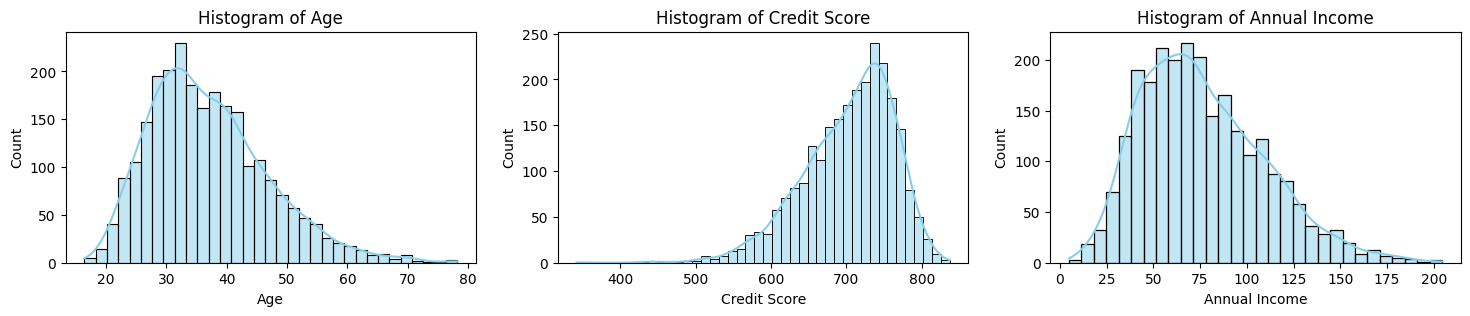

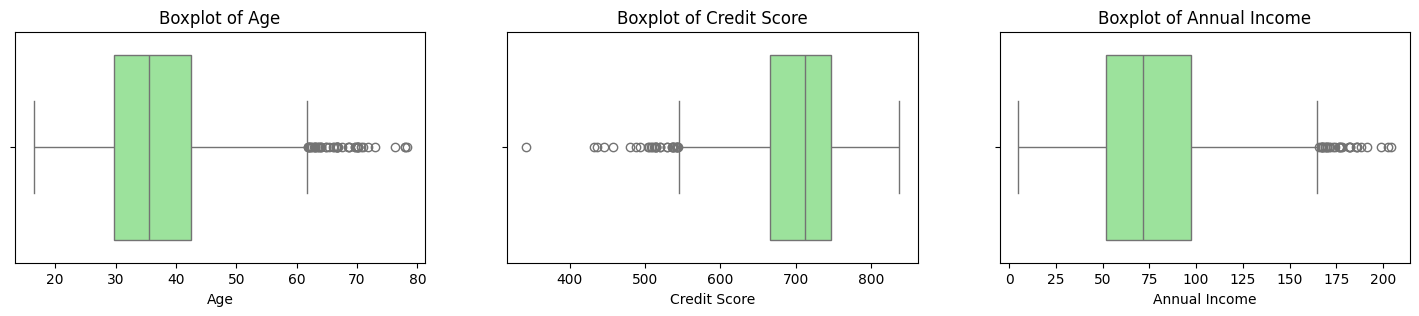

In [14]:
features = ['Age', 'Credit Score', 'Annual Income']
histplot_boxplot(data, features)

- Age & Annula Income exhibit a right side skewed distribution. Outliers are present in both the Age & annual Income.

- Credit Score has left side skewed distribution.



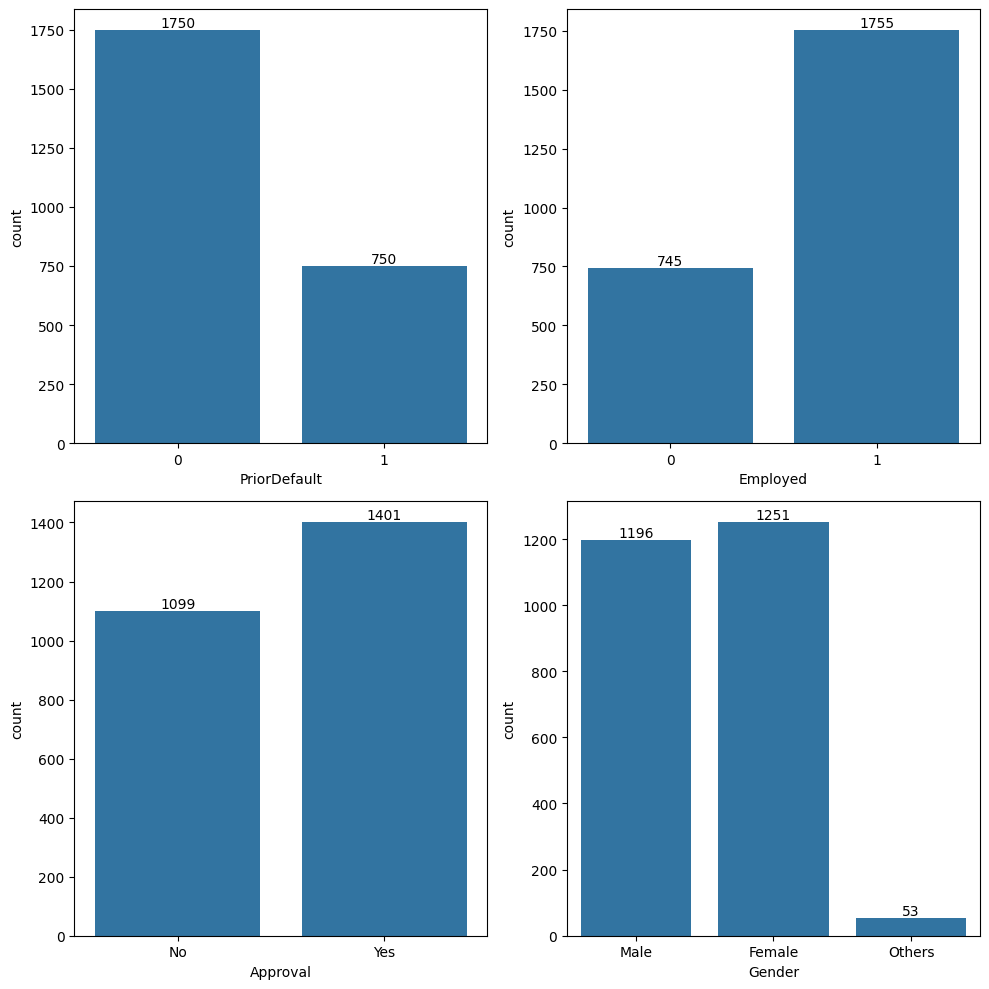

In [15]:
plt.figure(figsize = (10, 10))

features_X = ['PriorDefault', 'Employed', 'Approval', 'Gender']

for k, feature in enumerate(features_X) :
  plt.subplot(2, 2, k + 1)
  plot_1 = sns.countplot(data=df, x = feature)

  for value in plot_1.containers:
    plot_1.bar_label(value)

plt.tight_layout()
plt.show()

- ~750 applicant's have there prior default histroy. ( which is 30% of applicant's)

- Total 1755 applicant's were employeed. ( which is 70% )

- Total 1401 applicant's were loan has been approved. ( 56% applicant's got apprval )

- Most frequency of applicants are female. ( 50 % were female )

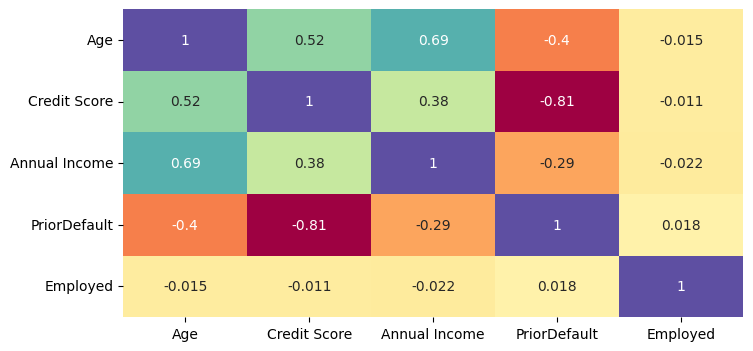

In [16]:
# NUmerical attributes correlation's
plt.figure(figsize= (8,4))
sns.heatmap(data = df.select_dtypes(include = ['number']).corr(), annot = True, cbar = False, cmap = 'Spectral' )
plt.show()

Here **Age & Credit Score** has **moderate correlation** between them.

**Age & Annual Income** has **high correlation** it's like if more age more income (hypothisis)

**Age - PriorDefault** & **Age - Employee** both has negative correlation.

**Credit Score & annual Income** has low correaltion.

**Prior Defalut & Credit Score** has high negative correlation between them. if loan default increases, credit score will decreses.



<Figure size 1800x800 with 0 Axes>

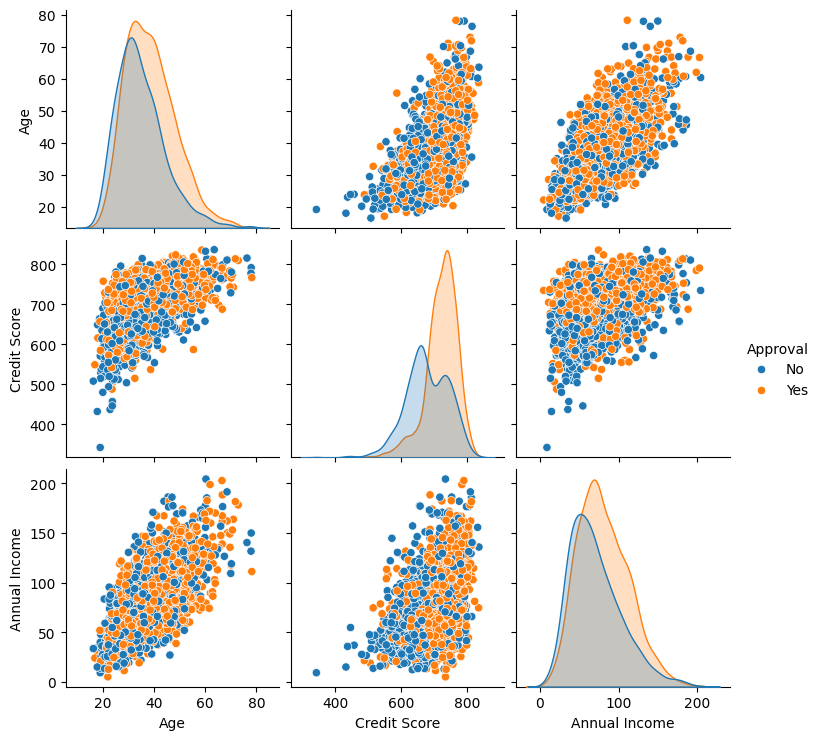

In [17]:
plt.figure(figsize = (18, 8))
sns.pairplot(data = df, vars = df[['Age', 'Credit Score', 'Annual Income']], hue = 'Approval', diag_kind= 'kde')
plt.show()

- In Age vs. Annual Income, loan approvals are not consistent. Some applicants with lower age and lower income are approved, while others with similar profiles are rejected. This suggests that age and income alone are not strong deciding factors.

- In Credit Score vs. Annual Income, most applicants with a credit score above 600–610 tend to get approved, even if their income is relatively low. However, there are cases where applicants with high income and good credit scores are still rejected, indicating other factors may also influence the decision.

- In Credit Score vs. Age, applicants with higher credit scores (around ≥ 610) are more likely to be approved, regardless of age. Although a few exceptions exist, credit score appears to be a stronger indicator compared to age.

- In Credit Score vs. Annual Income, applicants with both high income and high credit scores (>610) are generally approved, but some are still rejected. Similarly, applicants with low income and low credit scores are more likely to be rejected.

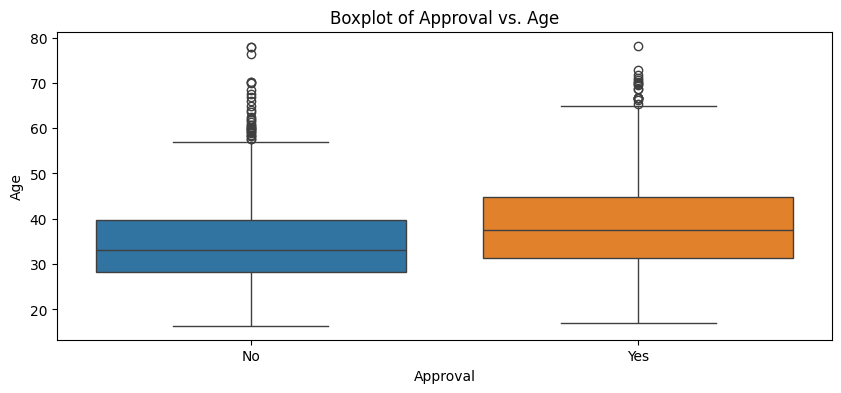

In [18]:
boxplot(df, 'Approval', 'Age')

- From both the side (loan rejected & loan Approved) minimum age of applicant is ~18.

- 25% of applicant's age is less than ~32-34 rejected cases. 25% of applicant's age is than ~55 year's old.

- Outliers are present in upper viscus.

- Age is not influencing the loan approval or rejection that much.


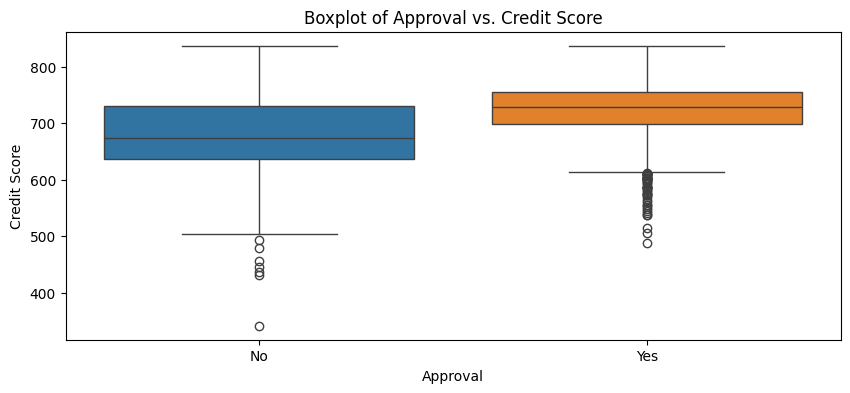

In [19]:
boxplot(df, 'Approval', 'Credit Score')

- Maximum credit score applicant's has also got loan rejection.

- In Loan rejected data median of Credit score is 670-680.

- In loan Approveed cases median credit score >=710-710.

- there is a high chances of loan approval on credit score >= 720.

- In both cases outliers are present.

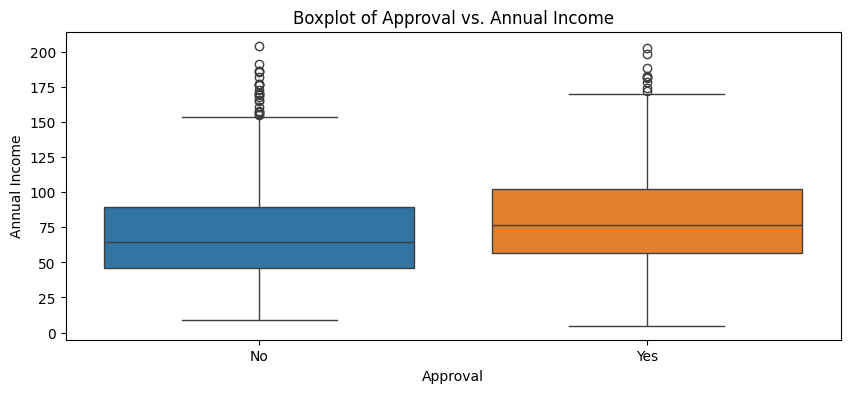

In [20]:
boxplot(df, 'Approval', 'Annual Income')

Applicants with higher income have a better chance of getting loan approval.
The median income of approved applicants is higher compared to rejected applicants.

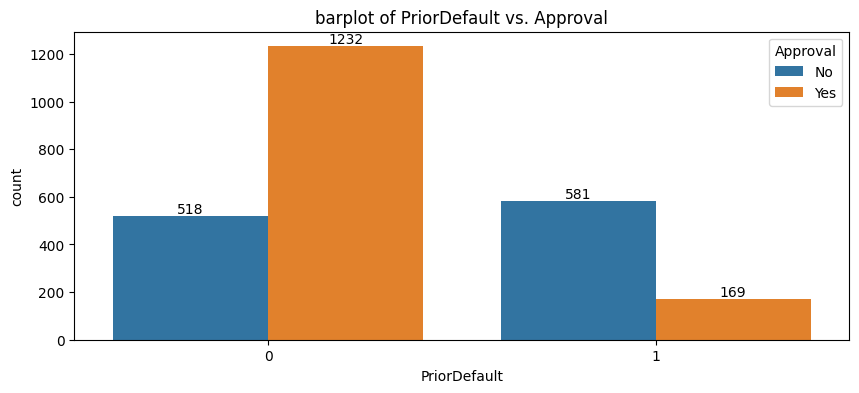

In [21]:
bar_plot(df, 'PriorDefault', 'Approval')

Applicants with no prior credit default history (0) have a higher likelihood of getting loan approval.

This feature appears to have a strong influence on the approval decision.
However, there are some cases where applicants with a prior default history (1) were still approved, indicating that other factors also contribute to the final decision.

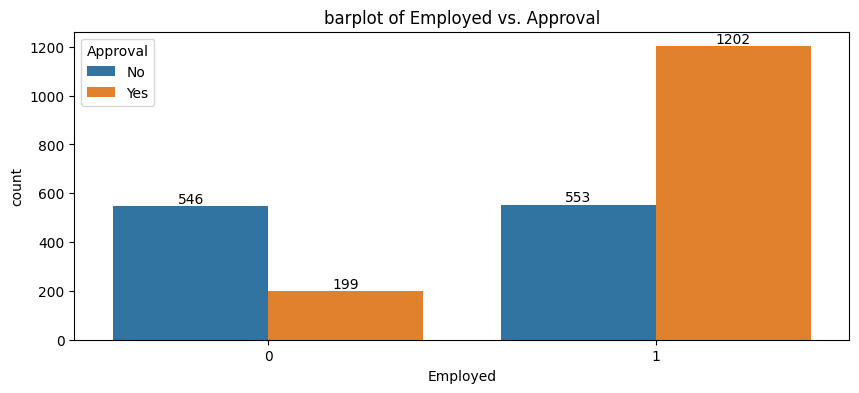

In [22]:
bar_plot(df, 'Employed', 'Approval')

Employed applicants have a higher likelihood of getting loan approval. Among the approved cases, approximately 68% are employed, while 32% are not employed.

However, employment alone is not a decisive factor. There are 199 employed applicants whose loan applications were rejected, indicating that other factors also significantly influence the rejection decision.

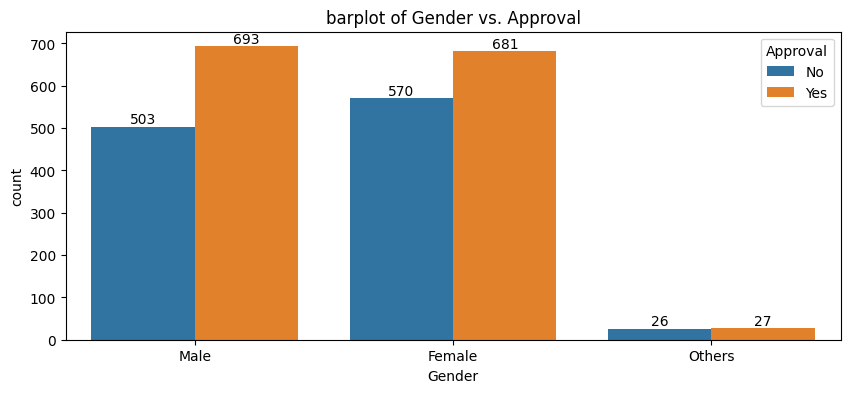

In [23]:
bar_plot(df, 'Gender', 'Approval')

The graph indicates that gender does not clearly separate or define distinct regions for loan approval and rejection.

Additionally, there are a few customers who have not specified their gender, which may affect the completeness of the analysis.

# **Data Prepration for model**

In [24]:
# Defining the dependent & independent variables

X = df.drop(['Approval'], axis= 1)
y = df['Approval']

In [25]:
# Creating a dummy varibales for categorical column

X = pd.get_dummies(
    X,
    columns = X.select_dtypes(include = ['object', 'category']).columns.tolist(),
    drop_first = True
).astype(float)

In [26]:
y.unique()

array(['No', 'Yes'], dtype=object)

In [27]:
# for same we doing label encoding for y data (dependent variable)

y = y.map({'Yes': 1, 'No': 0})
y.head()

,Approval
0,0
1,0
2,0
3,0
4,0


In [28]:
# we spliting the data for training and testing

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.20,
    stratify= y ,
    random_state= 4 #To make sure that the train and test datasets have the same proportion of target classes as the original dataset.
)

# stratify is used for mostly classification problems, imbalanced dataset

In [29]:
print(f"Shape of training dataset : {X_train.shape} \n")
print(f"Shape of test dataset : {X_test.shape} \n")
print("Prcentage of classes in training set : \n")
print(f" {y_train.value_counts(normalize=True)*100} \n")
print(f"{y_test.value_counts(normalize=True)*100} \n")

Shape of training dataset : (2000, 7) 

Shape of test dataset : (500, 7) 

Prcentage of classes in training set : 

 Approval
1   56.05
0   43.95
Name: proportion, dtype: float64 

Approval
1   56.00
0   44.00
Name: proportion, dtype: float64 



# **Building model (decision tree)**

In [30]:
# creating an intance of the decision tree 1
dtree1 = DecisionTreeClassifier(random_state=42)

dtree1.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

## **Evaluation matrics ( Checking model performance )**

In [31]:
# definfing a function to compute different matrics to check performance of a classification model building

def model_performance_classification(model, preictors, target):
  # predicting independent variables
  y_pred = model.predict(preictors)

  # to compute accuracy
  acc_score = accuracy_score(target, y_pred)
  # to compute recall
  recall = recall_score(target, y_pred)
  # to compute precision
  precision = precision_score(target, y_pred)
  # to compute f1 score
  f1 = f1_score(target, y_pred)

  # creating a df for this matrics

  df_pred = pd.DataFrame({
      "Accuracy": acc_score,
      "Recall" : recall,
      "Precision" : precision,
      "F1" : f1
  }, index = [0])

  return df_pred

In [32]:
# ploting a confusion matrics
def plot_confusion_matrics(model, predictor, target):

  # Predict the target values using the provided model and predictors
  y_pred = model.predict(predictor)

  # Compute the confusion matrix compairing the true target values with the predicted values
  cm = confusion_matrix(target, y_pred)

  # create a labels for each cell in the confusion matrix with both count and percentage
  labels = np.asarray(
      [
          ["{0:0.0f}".format(item) + "\n{0:.2%}".format( item / cm.flatten().sum()) for item in cm.flatten()]
      ]
  ).reshape(2, 2)

  plt.figure(figsize = (6,4))

  sns.heatmap(cm, annot = labels, cmap = 'Spectral', fmt = "")

  plt.ylabel("Actual Label")
  plt.xlabel("Predicted Label")



**We want to Maximize F1 score to ensure that we reduce both the chances of approving non-credible applications as well as rejecting credible onse.**

#### **Confusion Matrics for Train data**

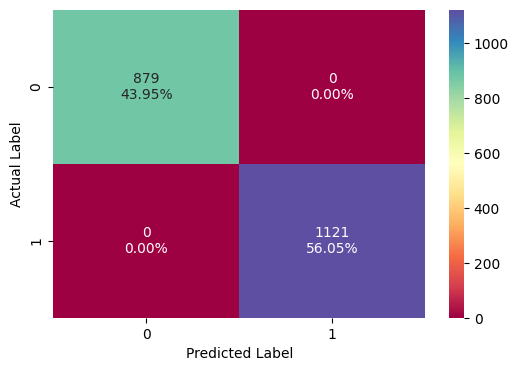

In [106]:
# confusion matrics for train data
plot_confusion_matrics(dtree1, X_train, y_train)

The confusion matrix on the training data shows strong performance with no misclassifications.

The model has correctly predicted all actual positive cases, indicating perfect alignment between actual and predicted values.

Overall, the model is performing exceptionally well on the training dataset.

In [107]:
# error rate
y_pred_train = dtree1.predict(X_train)
cm1 = confusion_matrix(y_train, y_pred_train)
TP  = cm1[0, 0]   # True Negative
FP = cm1[0,1]     # False Positive
FN = cm1[1,0]     # False Negative
TP = cm1[1,1]     # True Positive


error_rate_train = ( FP + FN ) / (TP + TN + FP + FN)
error_rate_train


np.float64(0.0)

In [108]:
evalution_df_train = model_performance_classification(dtree1, X_train, y_train)

# assigning new column as a error rate
evalution_df_train['Error Rate'] = error_rate_train

evalution_df_train

,Accuracy,Recall,Precision,F1,Error Rate
0,1.0,1.0,1.0,1.0,0.0


All the evaluation metrics are equal to 1, indicating excellent model performance. ( Also error rate is 0 )

#### **Confusion Matrics for Test data**

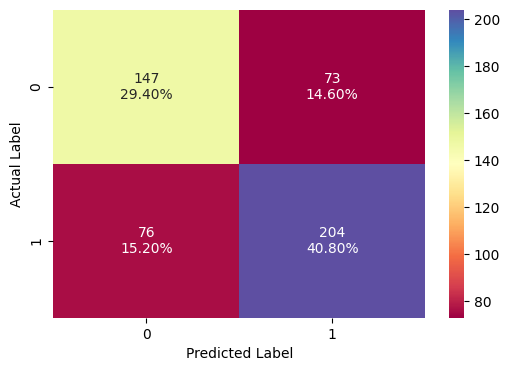

In [36]:
plot_confusion_matrics(dtree1, X_test, y_test)

here, 73 case are showing as a apprvoed in predicted but actualy it has rejected.

76 cases were showing as a Rejected in predicted but in actual it was apprvoed cases.


##### **Checking evaluation of model**

In [109]:
# error rate calculating
y_pred_test = dtree1.predict(X_test)
cm2 = confusion_matrix(y_test, y_pred_test)
TP = cm2[0,0]
TN = cm2[1,1]
FP = cm2[0,1]
FN = cm2[1,0]

error_rate_test = ( FP + FN ) / ( FP + FN + TP + TN )
error_rate_test

np.float64(0.298)

In [110]:
evalution_df_test = model_performance_classification(dtree1, X_test, y_test)
evalution_df_test['Error Rate'] = error_rate_test
evalution_df_test

,Accuracy,Recall,Precision,F1,Error Rate
0,0.702,0.728571,0.736462,0.732496,0.298


The model’s performance on the test data has decreased compared to the training data, **indicating overfitting**

There is a relatively higher error rate on the test dataset.

In [194]:
display("Evaluation Matrics for train data")
display(evalution_df_train)
display("Evaluation Matrics for test data")
display(evalution_df_test)

'Evaluation Matrics for train data'

,Accuracy,Recall,Precision,F1,Error Rate
0,1.0,1.0,1.0,1.0,0.0


'Evaluation Matrics for test data'

,Accuracy,Recall,Precision,F1,Error Rate
0,0.702,0.728571,0.736462,0.732496,0.298


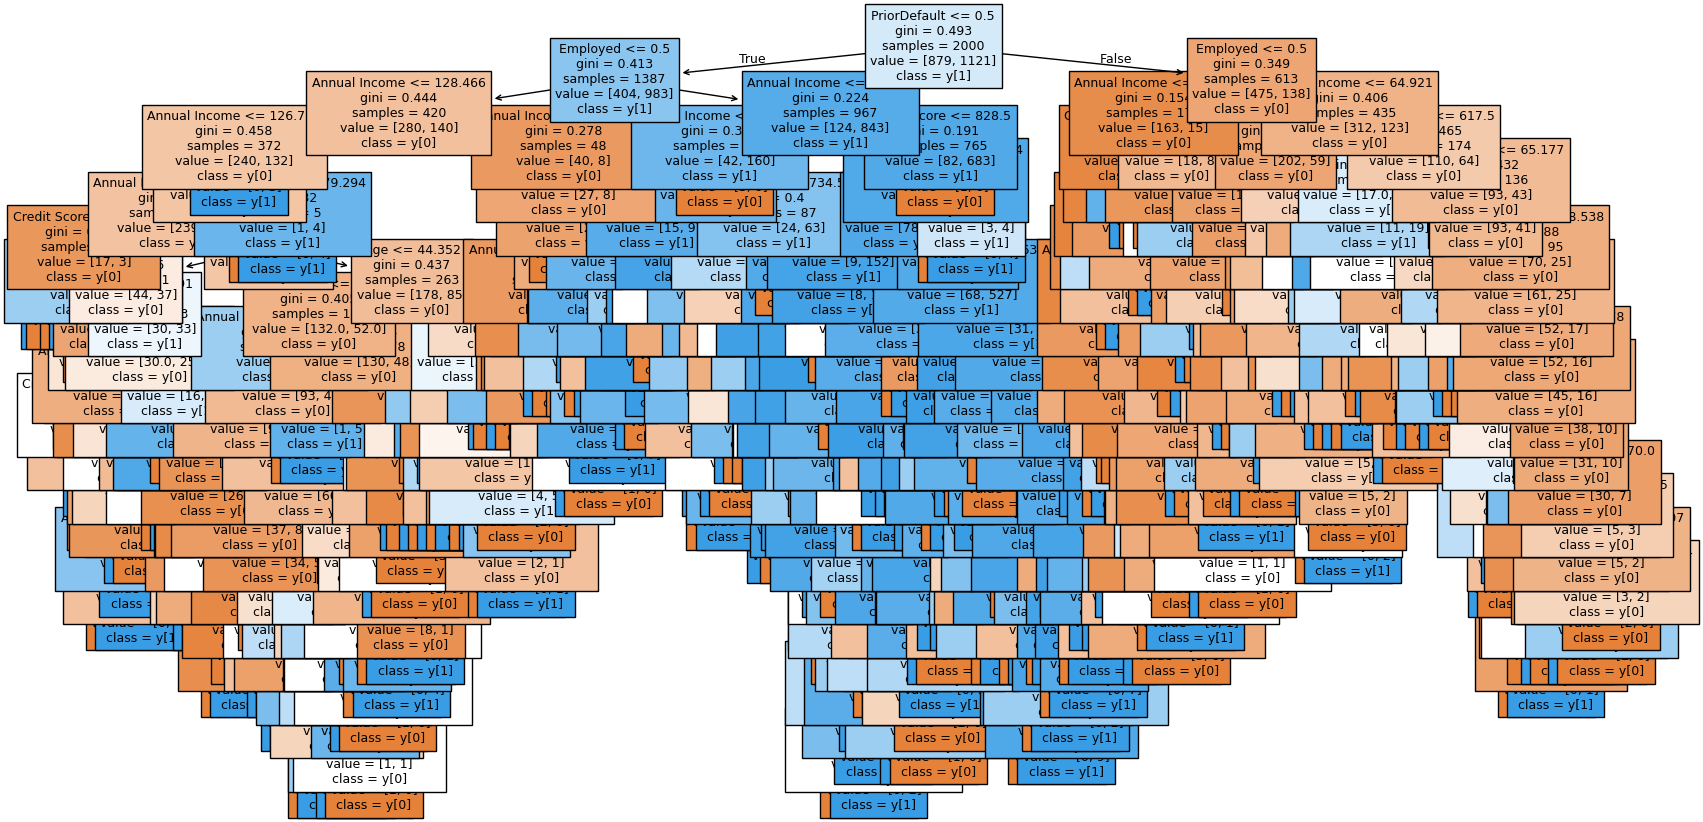

In [193]:
# list of the feature name in X_train
feature_names = X_train.columns.tolist()

# set the figure size for the plot
plt.figure(figsize = (20, 10))

# plotting the decision tree
out = tree.plot_tree(
    dtree1,
    feature_names=feature_names,
    class_names=True,   # or ['Rejected', 'Approved']
    filled=True,
    fontsize=9
)


# displaying the plot
plt.show()

**If Model got Overfitting then,**

- we can control its complexity by limiting depth. **(max_depth = )**

- increasing minimum samples for splits and leaves. **( min_samples_leaf = )**

- applying pruning techniques. **( ccp_alpha = )**

- If still overfitting → use Random Forest

# **Decision Tree ( pre-pruning )**

In [131]:
# defining the parameter of the tree ro iterate over

max_depth_values = np.arange(4, 10, 2)
max_leaf_nodes_values = np.arange(10, 40, 6)
min_samples_split_values = np.arange(10, 40, 6)

# initialize variables to store best model & its performance

best_estimator = None
best_score_diff = float('inf')

# iterate over all combinations

for max_dept in max_depth_values :
  for max_leaf_nodes in max_leaf_nodes_values :
    for min_samples_split in min_samples_split_values :

      # initialize the tree with the current set of paramenters
      estimator = DecisionTreeClassifier(
          max_depth = max_dept,
          max_leaf_nodes= max_leaf_nodes,
          min_samples_split = min_samples_split,
          random_state = 42
      )

      # fit the data on model to train
      estimator.fit(X_train, y_train)

      # make prediction on the training data

      y_pred_train = estimator.predict(X_train)
      y_pred_test = estimator.predict(X_test)

      #calculating F1 score
      f1_score_train = f1_score(y_train, y_pred_train)
      f1_score_test = f1_score(y_test, y_pred_test)

      # calculating the absolute disfference between trainig & F1 scores
      score_diff = abs(f1_score_train - f1_score_test)

      # update the best estimator and best score.

      if score_diff < best_score_diff :
        best_score_diff = score_diff
        best_estimator = estimator

In [132]:
# create instance for dtree 2
dtree2 = best_estimator

# fitting the data in model
dtree2.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=np.int64(4), max_leaf_nodes=np.int64(10),
                       min_samples_split=np.int64(28), random_state=42)

##### **Model Evalution (After Pre-pruning)**

**On train data**

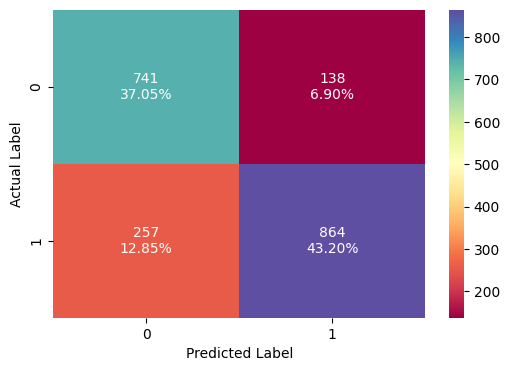

In [133]:
# plotting confusion matrics for train data ( after pre-pruning )
plot_confusion_matrics(dtree2, X_train, y_train)

In [134]:
# Calculating error rate
error_y_pred_train = dtree2.predict(X_train)
Error_cm_train = confusion_matrix(y_train, error_y_pred_train)

TP = Error_cm_train[0,0]
FP = Error_cm_train[0,1]
FN = Error_cm_train[1,0]
TN = Error_cm_train[1,1]
error_rate_train = (FP + FN) / (FP + FN + TN + TP)
error_rate_train

np.float64(0.1975)

In [135]:
# adding the train data into model evalution function where we got the model performance in term of accuracy, recall, precision, F1 score
evaluation_train_data_after_pre_pruning = model_performance_classification(dtree2, X_train, y_train )

# we have externally calculated error rate so adding into it evalution df
evaluation_train_data_after_pre_pruning['Error Rate'] = error_rate_train
evaluation_train_data_after_pre_pruning

,Accuracy,Recall,Precision,F1,Error Rate
0,0.8025,0.77074,0.862275,0.813943,0.1975


After applying pre-pruning, the confusion matrix can be interpreted as follows:

**True Positive (TP = 741):** These applications were actually rejected, and the model correctly predicted them as rejected.

**False Negative (FN = 138):** These applications were actually rejected, but the model incorrectly predicted them as approved.

**False Positive (FP = 257):** These applications were actually approved, but the model incorrectly predicted them as rejected.

**True Negative (TN = 864):** These applications were actually approved, and the model correctly predicted them as approved.

Overall, the model performs well in identifying both approved and rejected applications, with some misclassifications in both categories. error rate is 20%

##### **Model Evalution (After Pre-pruning)**

**On test data**

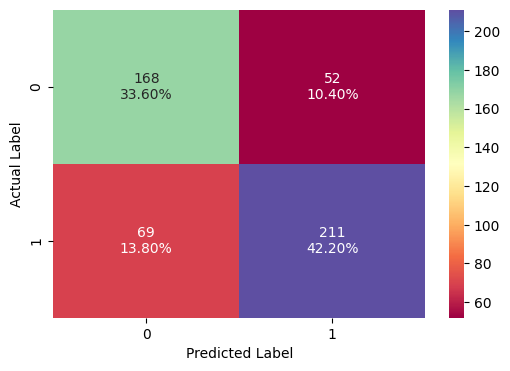

In [136]:
# plotting a confusion matrics

plot_confusion_matrics(dtree2, X_test, y_test)

In [137]:
# Calculating predicted value for test data after pre-pruning
error_y_pred_test = dtree2.predict(X_test)

# confusion matrics on test data
Error_cm_test = confusion_matrix(y_test, error_y_pred_test)

# finding TP, FN, FP, TN
TP = Error_cm_test[0,0]
FP = Error_cm_test[0,1]
FN = Error_cm_test[1,0]
TN = Error_cm_test[1,1]

# error rate formula
error_rate_test = ( FP + FN ) / (FP + FN + TP + TN)
# final error rate
error_rate_test

np.float64(0.242)

In [138]:
evaluation_test_data_after_pre_pruning = model_performance_classification(dtree2, X_test, y_test)
evaluation_test_data_after_pre_pruning['Error Rate'] = error_rate_test
evaluation_test_data_after_pre_pruning

,Accuracy,Recall,Precision,F1,Error Rate
0,0.758,0.753571,0.802281,0.777164,0.242


here we can see, in COnfusion matrics plot

**TP (True Positive)** : 168 cases was actually rejected & model correctly predicted them as a Rejected.

**FN (False Positive)** : 53 cases was actually Rejected & model is predicted as a Approved. ( model prediected Incorrectly ).

**FP (False Positive)** : 69 cases was actually Approved & model predicted incorrectly like not approved(Rejected).

**TN (True Negative)** : 211 cases was actually Apprvoed & model predicted correctly as a approved.

In evaluation matrics, **accuracy is 77%** & **F1 score is 0.78** test data.

In [139]:
display("Evalution matrics on Train data After pre-pruning")
display(evaluation_train_data_after_pre_pruning)
print()
display("Evalution matrics on Test data After pre-pruning")
display(evaluation_test_data_after_pre_pruning)

'Evalution matrics on Train data After pre-pruning'

,Accuracy,Recall,Precision,F1,Error Rate
0,0.8025,0.77074,0.862275,0.813943,0.1975


'Evalution matrics on Test data After pre-pruning'

,Accuracy,Recall,Precision,F1,Error Rate
0,0.758,0.753571,0.802281,0.777164,0.242


here, we can see Our model is reduced overfitting.
**Accuarcy** is droped from 80% to 76% which is **4% drop** from train to test (very small gap).

**F1 score** is droped from 81% to 78% which is **3% drop** from train to test(very small gap).

This is clearly indecates model is **Balanced Model**

**The model show performance well on train data & also test data (unseen data). However the gap is not very large, the model is still generalizes on unseen data**

We can work on Overfitting by **tune Hyperparameters**

## **Visualizing the decision Tree**

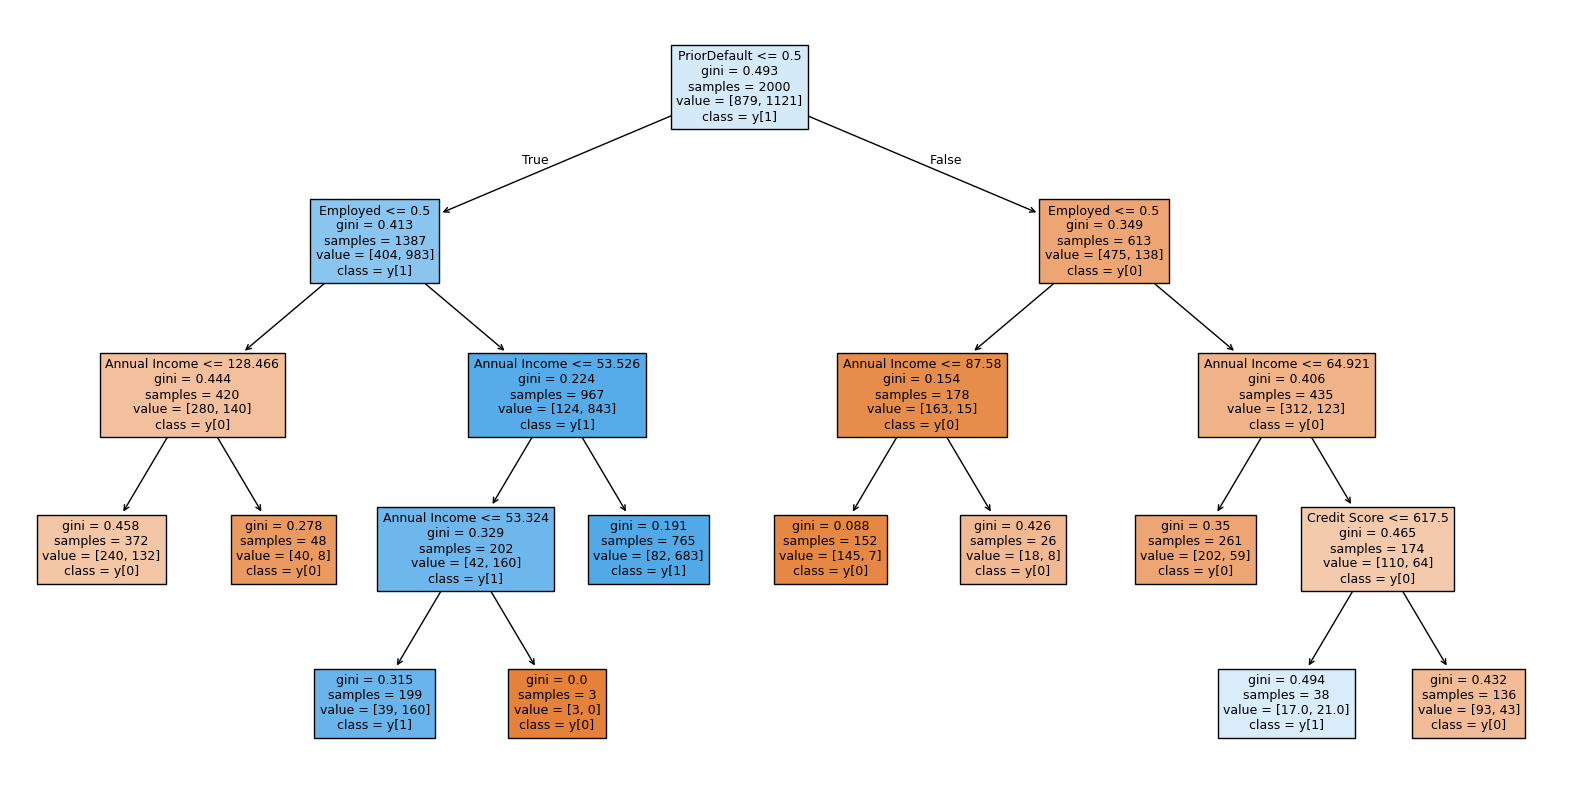

In [140]:
# list of the feature name in X_train
feature_names = X_train.columns.tolist()

# set the figure size for the plot
plt.figure(figsize = (20, 10))

# plotting the decision tree
out = tree.plot_tree(
    dtree2,
    feature_names=feature_names,
    class_names=True,   # or ['Rejected', 'Approved']
    filled=True,
    fontsize=9
)


# displaying the plot
plt.show()

# **Decision Tree ( Post - Pruning  )**

In [141]:
# create an instance of the decision tree model
clf = DecisionTreeClassifier(random_state = 42)

# Compute the cost complexity pruning path for the model using the training data
path = clf.cost_complexity_pruning_path(X_train, y_train)

# Extract the array of effective alphas from the pruning path
ccp_alphas = abs(path.ccp_alphas)

# Extract the array of total empurities at each alpha along the pruning path
impurities = path.impurities

In [142]:
pd.DataFrame(path)
# ccp_alphas

,ccp_alphas,impurities
0,0.000000,0.000000
1,0.000317,0.000950
2,0.000329,0.001936
3,0.000375,0.002686
4,0.000375,0.003436
...,...,...
148,0.001837,0.301291
149,0.002098,0.303389
150,0.004976,0.308366
151,0.084892,0.393258


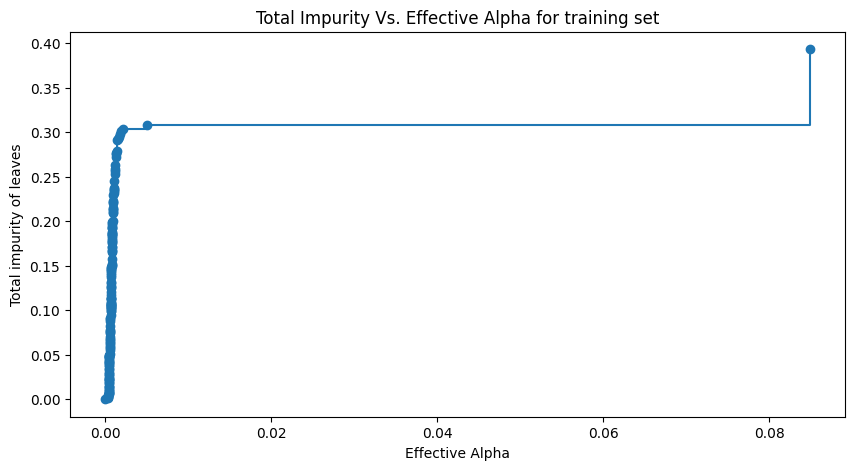

In [143]:
# ploting this data no graph

# figure size
fig, ax = plt.subplots(figsize=(10, 5))

# plotting the total impurities versus effective alphas, excluding the last value using
# markers at each datapoint and connecting them with steps.
ax.plot(ccp_alphas[:-1], impurities[:-1], marker = "o", drawstyle = "steps-post")

# set the x-axis label
ax.set_xlabel("Effective Alpha")

# set the y-axis label
ax.set_ylabel("Total impurity of leaves")

# Set the title of the plot
ax.set_title("Total Impurity Vs. Effective Alpha for training set");

All the alphas on 0

- Next, we train a decision tree using the effective alphas.

- The last value in ccp_alphas is the alpha value that prunes the hole tree, leaving the corresponding tree with one node.

In [144]:
# Initialze an empty list to store the decision tree classifiers
clfs = []

# iterate over each ccp_alphas value extracted from the cost complexity pruning path.
for ccp_alpha in ccp_alphas :
  # create an instance of the DecisionTreeClassifier
  clf = DecisionTreeClassifier(ccp_alpha=ccp_alpha , random_state = 42 )

  # fit the classifier to the training data
  clf.fit(X_train, y_train)

  clfs.append(clf)

# print the number of nodes in the last tree along with its ccp_alpha value
print(
    "Number of nodes in the last tree is {} with ccp_alpha {}".format(
        clfs[-1].tree_.node_count, ccp_alphas[-1]
    )
)

Number of nodes in the last tree is 1 with ccp_alpha 0.09942194293609635


Moving ahead, we remove the last element in clfs and ccp_alphas as it corresponds to a trivial tree with only one nodes.

### **Accuracy vs Alpha for training and testing sets**

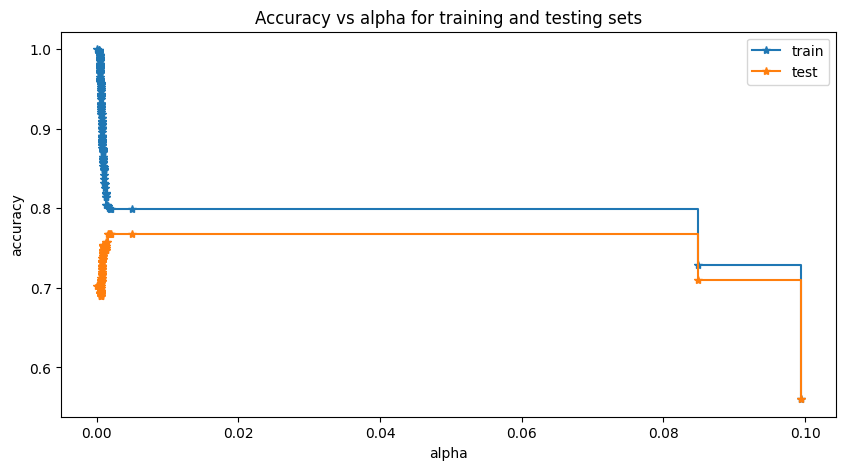

In [145]:
from matplotlib.lines import drawStyles
train_score = [clf.score(X_train, y_train) for clf in clfs]
test_score = [clf.score(X_test, y_test) for clf in clfs]

fig, ax = plt.subplots(figsize = (10, 5))
ax.set_xlabel("alpha")
ax.set_ylabel("accuracy")
ax.set_title("Accuracy vs alpha for training and testing sets")
ax.plot(ccp_alphas, train_score, marker = '*', label = "train", drawstyle = "steps-post")
ax.plot(ccp_alphas, test_score, marker = '*', label = "test", drawstyle = "steps-post")
ax.legend()
plt.show()


In [146]:
# checking the f1 score from train data

train_f1_scores = []

for clf in clfs :
  clf_pred_train = clf.predict(X_train)
  f1_train = f1_score(y_train, clf_pred_train)
  train_f1_scores.append(f1_train)

In [147]:
# checking f1 score from test data

test_f1_score = []

for clf in clfs :
  clf_pred_test = clf.predict(X_test)
  f1_test = f1_score(y_test, clf_pred_test)
  test_f1_score.append(f1_test)

**Plotting this f1 scores into a graph**

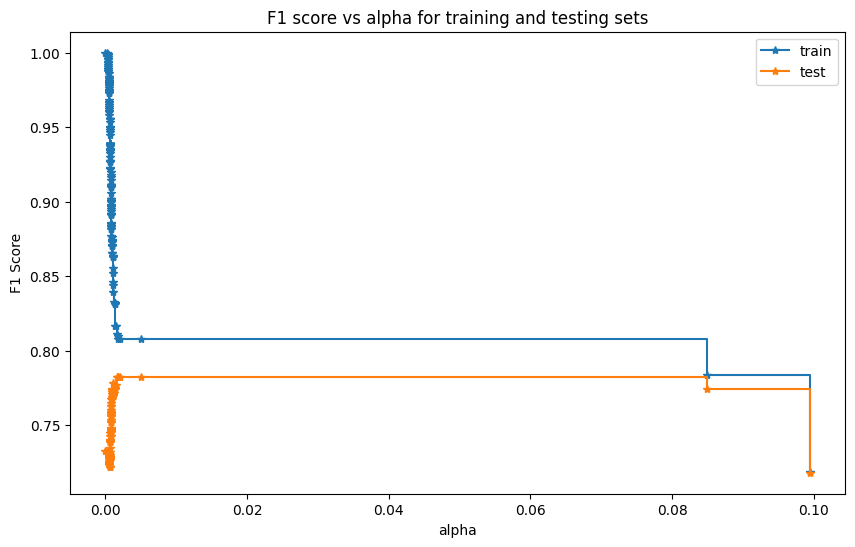

In [148]:
from matplotlib.lines import drawStyles

fig, ax = plt.subplots(figsize = (10, 6))
ax.set_xlabel("alpha")
ax.set_ylabel("F1 Score")
ax.set_title("F1 score vs alpha for training and testing sets")
ax.plot(ccp_alphas, train_f1_scores, marker = '*', label = "train", drawstyle = "steps-post")
ax.plot(ccp_alphas, test_f1_score, marker = '*', label = "test", drawstyle = "steps-post")
ax.legend()
plt.show()


In [149]:
pd.reset_option('display.float_format')

In [150]:

# creating the model where we get the highest test F1 score

index_best_model = np.argmax(test_f1_score)

# selecting the decision tree model corresponding to the highest test score
dtree3 = clfs[index_best_model]
print(dtree3)

DecisionTreeClassifier(ccp_alpha=np.float64(0.0016606215081313783),
                       random_state=42)


**Model Evalution for this dtree3**

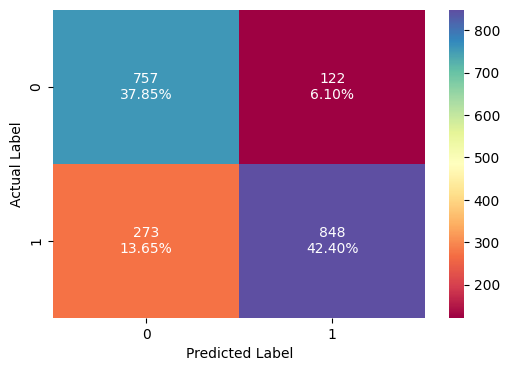

In [151]:
plot_confusion_matrics(dtree3, X_train, y_train)

In [166]:
# calculating model evaluation matrics
evaluation_train_data_after_post_pruning = model_performance_classification(dtree3, X_train, y_train)

In [183]:
# predicting a value for dtree3 for train data
error_y_pred_train_post_pruning = dtree3.predict(X_train)

# cm for dtree3 error_y_pred_train_post_pruning
cm_train_post_pruning = confusion_matrix(y_train, error_y_pred_train_post_pruning)

TP = cm_train_post_pruning[0,0]
FN = cm_train_post_pruning[0,1]
FP = cm_train_post_pruning[1,0]
TP = cm_train_post_pruning[1,1]

error_rate = (FP + FN) / (FP + FN + TP + TN)
evaluation_train_data_after_post_pruning['Error Rate'] = error_rate
evaluation_train_data_after_post_pruning

,Accuracy,Recall,Precision,F1,Error Rate
0,0.768,0.742857,0.825397,0.781955,0.272226


according to this confusion matrics on train data,

**TP ( True Positive )** : 757 cases was **actually Recjected** & our **model predicted correct.**  

**FN ( False Negative )** : 122 cases was **Actually rejected** & model **predicted as a approved**, **incorrectly predicted.**

**FP ( False Positive )** : 273 cases was **actually apprvoed** but our model is **predicted as a Rejected**. **Incorrectly predicted.**

**TP ( True Positive )** : 848 cases was **actually apprvoed** & our model also predicted same, **Model predict correctly.**

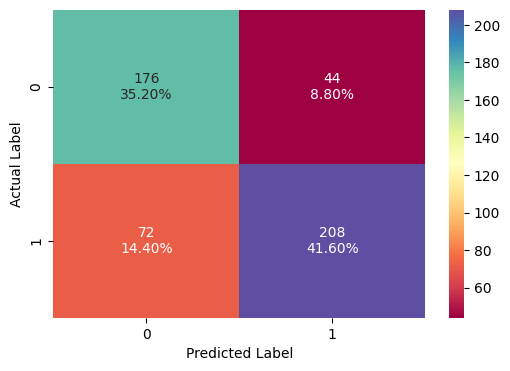

In [184]:
plot_confusion_matrics(dtree3, X_test, y_test)

In [185]:
# calculating model performance matrics on test data
evaluation_test_data_after_post_pruning = model_performance_classification(dtree3, X_test, y_test)

In [198]:
# predicting a values for test data dtree3
error_y_pred_test_post_pruning = dtree3.predict(X_test)

# confusion matrics for dtree3 model on test data
cm_test_post_pruning = confusion_matrix(y_test, error_y_pred_test_post_pruning)

# findig the error rate

TP = cm_test_post_pruning[0,0]
TN = cm_test_post_pruning[1,1]
FP = cm_test_post_pruning[1,0]
FN = cm_test_post_pruning[0,1]

error_rate = (FP + FN) / ( TP + TN + FP + FN )
evaluation_test_data_after_post_pruning['Error Rate'] = error_rate
evaluation_test_data_after_post_pruning



,Accuracy,Recall,Precision,F1,Error Rate
0,0.768,0.742857,0.825397,0.781955,0.232


according to above confusion matrics on test data,

**TN (True Negative)** : 176 cases was **Actually Rejected** & **model predicted Rejected, Correctly Predicted.**

**FN (False Negative)** : 44 cases was was **Actually Rejected** but our **model predicted as a Approved, Incorrectly Predicted**

**FP (False Positive)** : 72 cases was **Actually Approved** but **model predicted as Rejcted, Incorrectly Predicted.**

**TP (True Positive)** : 208 cases was **Actually Approved** & **model predicted Approved, Correctly Approved.**

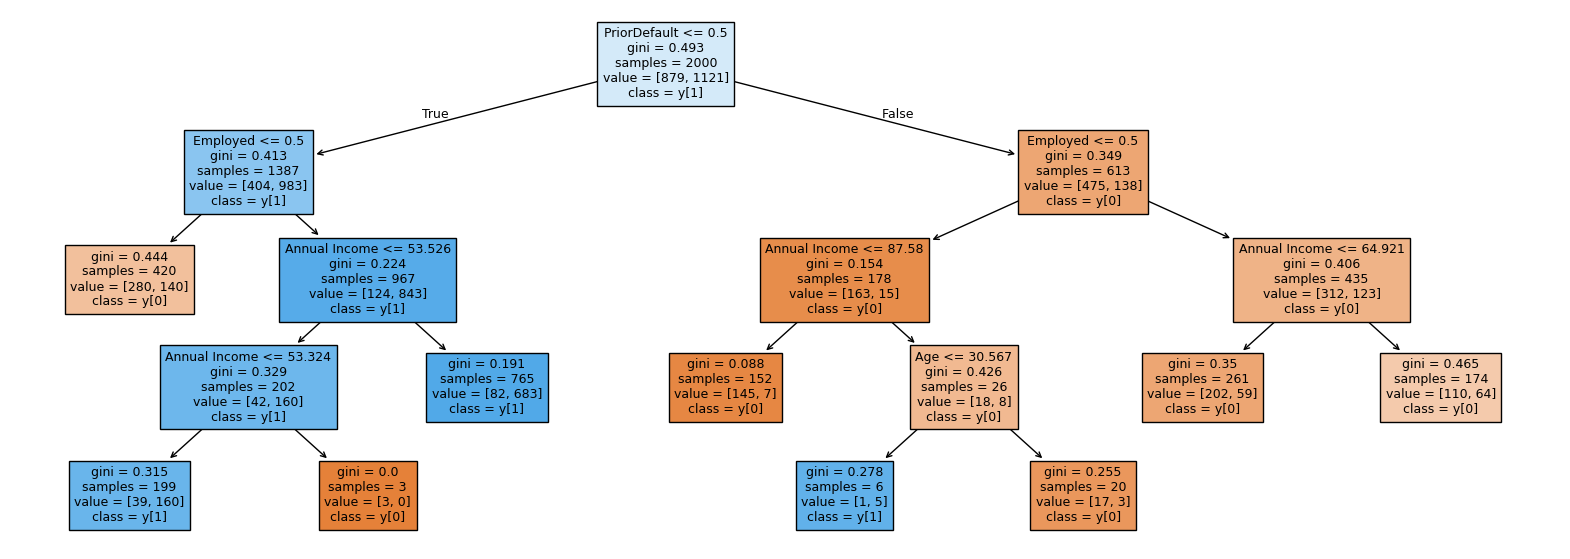

In [199]:
# list of the feature name in X_train
feature_names = X_train.columns.tolist()

# set the figure size for the plot
plt.figure(figsize = (20, 7))

# plotting the decision tree
out = tree.plot_tree(
    dtree3,
    feature_names=feature_names,
    class_names=True,   # or ['Rejected', 'Approved']
    filled=True,
    fontsize=9
)


# displaying the plot
plt.show()

# **Model Performance Comparison and Final Model Selection**

In [200]:
# training performance comparison

model_train_comp_df = pd.concat(
    [
        evalution_df_train.T,
        evaluation_train_data_after_pre_pruning.T,
        evaluation_train_data_after_post_pruning.T
    ],
    axis = 1
)

model_train_comp_df.columns = [
    "Decision Tree (Sklearn default)",
    "Decision Tree (Pre-Pruning)",
    "Decision Tree (Post-Pruning)"
]

In [201]:
# test performance comparison

model_test_comp_df = pd.concat(
    [
        evalution_df_test.T,
        evaluation_test_data_after_pre_pruning.T,
        evaluation_test_data_after_post_pruning.T
    ],
    axis = 1
)

model_test_comp_df.columns = [
    "Decision Tree (Sklearn default)",
    "Decision Tree (Pre-Pruning)",
    "Decision Tree (Post-Pruning)"
]

In [202]:
display("Training Performance comparison")
display(model_train_comp_df)
print()
display("Test Performance comparison")
display(model_test_comp_df)

'Training Performance comparison'

,Decision Tree (Sklearn default),Decision Tree (Pre-Pruning),Decision Tree (Post-Pruning)
Accuracy,1.0,0.802500,0.768000
Recall,1.0,0.770740,0.742857
Precision,1.0,0.862275,0.825397
F1,1.0,0.813943,0.781955
Error Rate,0.0,0.197500,0.272226


'Test Performance comparison'

,Decision Tree (Sklearn default),Decision Tree (Pre-Pruning),Decision Tree (Post-Pruning)
Accuracy,0.702000,0.758000,0.768000
Recall,0.728571,0.753571,0.742857
Precision,0.736462,0.802281,0.825397
F1,0.732496,0.777164,0.781955
Error Rate,0.298000,0.242000,0.232000


##### **Both the pre-pruned & post-pruned decision tree exhibit generalized performance.**

**- The Post-Pruned decision tree has an almost same performance on test & train data. on F1**

1) Post-Pruning model took features like prior default, employee status, Annual income & age for decision making.  

2) post pruning Accuracy, Recall, Precision, F1 score has same in both train & test dataset.

**- The Pre-Pruned decision tree has an 3.68% droped on test data than train data F1.**

1) This model tooks features like prior default, employee status, Annual income, credit score for decision making.

2) pre-pruning Accuracy droped by 4%, Recall is droped by 2%, Precision droped by 6% & F1 score is droped by 4%.


**- In train dataset model got overfitting, Accuracy 1 to 0.7 decreased. poor genralization.**


**- In test data set Pruning improves model significantly, accuracy improves 0.70 to 0.75 & error reduced 0.29 to 0.24, recall is 0.753 which indicating after pruning model catching more positive cases.**


**- In post pruning model is more balanced & optimized.**

**- Pre-Pruning:**

✔ More stable

✔ Lowest error

✔ Balanced recall

**- Post-Pruning:**

✔ Best accuracy & precision

✔ Slightly aggressive pruning


## **🏆 Final Conclusion**

**Best model depends on business goal:**

   **✅ If you want overall balance:**

   👉 Pre-Pruning model is safest


   **✅ If you want higher accuracy & precision:**

 👉 Post-Pruning model is better

### **We'll move ahead with Pre-Pruned Decision Tree as our final model.**

### **Feature Importance**

Feature importances helps to understand the model and feature selection and improves model interpretability. Important fatures can be given more focus in data collection & preporcessing.

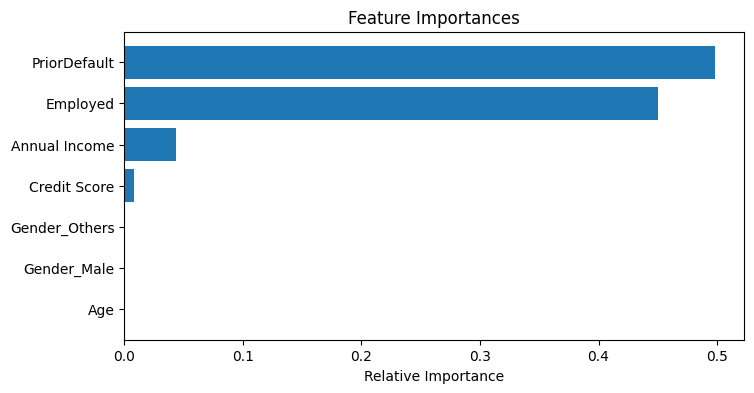

In [212]:
from ctypes import alignment
# importance of features in the tree building
importance = dtree2.feature_importances_
indices = np.argsort(importance)

plt.figure(figsize=(8, 4))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importance[indices], align = 'center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

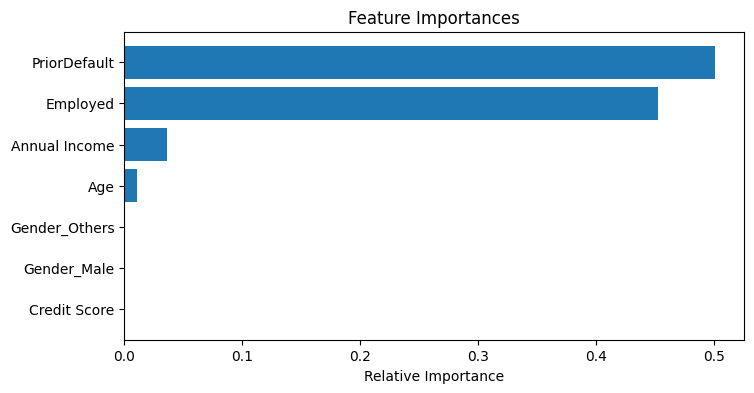

In [215]:
from ctypes import alignment
# importance of features in the tree building
importance = dtree3.feature_importances_
indices = np.argsort(importance)

plt.figure(figsize=(8, 4))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importance[indices], align = 'center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()